In [1]:
import numpy as np
from AttitudeAviary import *
from stable_baselines3 import DDPG 

In [2]:
SIM_FREQ_HZ = 240
AGGR_PHY_STEPS = 1 # 1 physics step per action/control command

env = AttitudeAviary(drone_model=DroneModel.CF2X,
                freq=SIM_FREQ_HZ,
                aggregate_phy_steps=AGGR_PHY_STEPS,
                gui=False,
                record=False,
                )

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/attitude_sb3_logs"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, log_dir)

In [4]:
from stable_baselines3.common.callbacks import EvalCallback
eval_env = AttitudeAviary(drone_model=DroneModel.CF2X,
                freq=SIM_FREQ_HZ,
                aggregate_phy_steps=AGGR_PHY_STEPS,
                gui=False,
                record=False,
                )
eval_env = Monitor(eval_env)

eval_callback = EvalCallback(eval_env,
            log_path="C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/attitude_sb3_logs",
            n_eval_episodes=2,
            eval_freq=1000,
            deterministic=True) 

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [5]:
model = DDPG('MlpPolicy', env, verbose=2, learning_starts=1000, batch_size=256)
model.learn(total_timesteps=100000, callback=eval_callback)

Using cpu device
Wrapping the env in a DummyVecEnv.
Eval num_timesteps=1000, episode_reward=-358.45 +/- 9.82
Episode length: 777.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 777      |
|    mean_reward     | -358     |
| time/              |          |
|    total timesteps | 1000     |
---------------------------------
New best mean reward!
Eval num_timesteps=2000, episode_reward=-155.51 +/- 25.99
Episode length: 195.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 195      |
|    mean_reward     | -156     |
| time/              |          |
|    total timesteps | 2000     |
| train/             |          |
|    actor_loss      | 2.14     |
|    critic_loss     | 0.00491  |
|    learning_rate   | 0.001    |
|    n_updates       | 933      |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len

In [6]:
model.save("attitude_sb3_logs/DDPG_Attitude")

In [7]:
history = np.load("attitude_sb3_logs/evaluations.npz")
rewards = np.average(history["results"], axis=1)
ep_lengths = np.average(history["ep_lengths"], axis=1)
print(rewards.shape)
print(ep_lengths.shape)

(100,)
(100,)


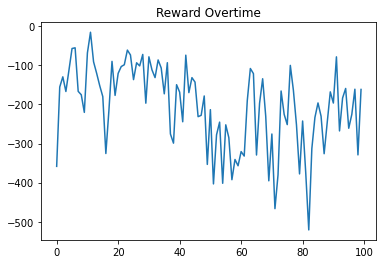

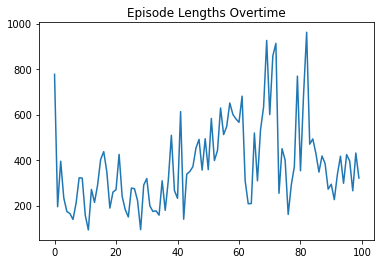

In [8]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Reward Overtime")
plt.show()
plt.plot(ep_lengths)
plt.title("Episode Lengths Overtime")
plt.show()

In [18]:
env = AttitudeAviary(drone_model=DroneModel.CF2X,
                freq=SIM_FREQ_HZ,
                aggregate_phy_steps=AGGR_PHY_STEPS,
                gui=False,
                record=False,
                )
obs = env.reset()
rew = []
for i in range(1*env.SIM_FREQ):
    action, _states = model.predict(obs)
    obs, reward, done, info = env.step(action)
    rew.append(reward)
    if i%env.SIM_FREQ == 0:
        env.render()
        print(done)
    if done:
        obs = env.reset()
env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[WARNING] BaseAviary.render() is implemented as text-only, re-initialize the environment using Aviary(gui=True) to use PyBullet's graphical interface

[INFO] BaseAviary.render() ——— it 0001 ——— wall-clock time 0.0s, simulation time 0.0s@240Hz (0.10x)
[INFO] BaseAviary.render() ——— drone 0 ——— x +00.00, y +00.00, z +05.00 ——— velocity +00.00, +00.00, +00.00 ——— roll -00.01, pitch +00.01, yaw +00.00 ——— angular velocity -0.0407, +0.0408, +0.0194 ——— 
False


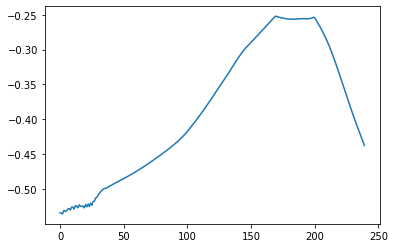

In [19]:
plt.plot(rew)